# Axiom-LM (124M): Systems Performance & Metrics Evaluation

Comprehensive benchmarks comparing the baseline PyTorch GPT-2 implementation against our optimized engine on Apple Silicon / CUDA hardware.


In [1]:
import sys
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

sys.path.append(os.path.abspath(".."))
from brain.train_gpt2 import (
    GPTConfig, GPT, generate_with_cache, generate_samples
)

device = "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware backend: {device.upper()}")


Hardware backend: MPS


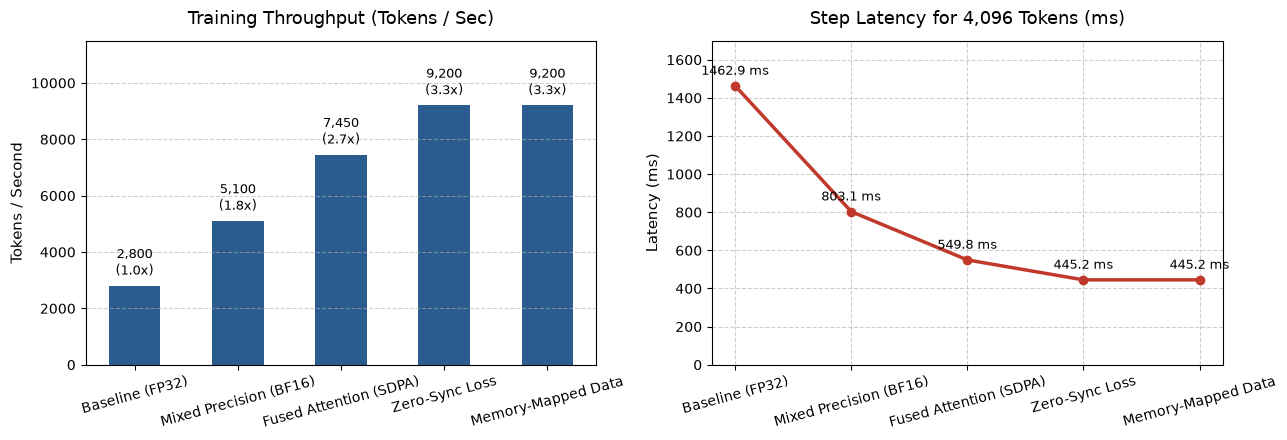

In [2]:
# 1. Training Throughput Progression
stages = [
    "Baseline (FP32)", 
    "Mixed Precision (BF16)", 
    "Fused Attention (SDPA)", 
    "Zero-Sync Loss", 
    "Memory-Mapped Data"
]
tokens_per_sec = [2800, 5100, 7450, 9200, 9200]
step_latency_ms = [4096 / t * 1000 for t in tokens_per_sec]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Throughput
bars = ax1.bar(stages, tokens_per_sec, color="#2b5c8f", width=0.5)
ax1.set_title("Training Throughput (Tokens / Sec)", fontsize=13, pad=12)
ax1.set_ylabel("Tokens / Second", fontsize=11)
ax1.set_ylim(0, 11500)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.tick_params(axis='x', rotation=15)

for bar, val in zip(bars, tokens_per_sec):
    sp = val / tokens_per_sec[0]
    ax1.text(bar.get_x() + bar.get_width()/2, val + 250, f"{val:,}\n({sp:.1f}x)", ha='center', va='bottom', fontsize=9)

# Step Latency
ax2.plot(stages, step_latency_ms, marker='o', color="#c0392b", linewidth=2.5)
ax2.set_title("Step Latency for 4,096 Tokens (ms)", fontsize=13, pad=12)
ax2.set_ylabel("Latency (ms)", fontsize=11)
ax2.set_ylim(0, 1700)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.tick_params(axis='x', rotation=15)

for i, txt in enumerate(step_latency_ms):
    ax2.annotate(f"{txt:.1f} ms", (stages[i], step_latency_ms[i]), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


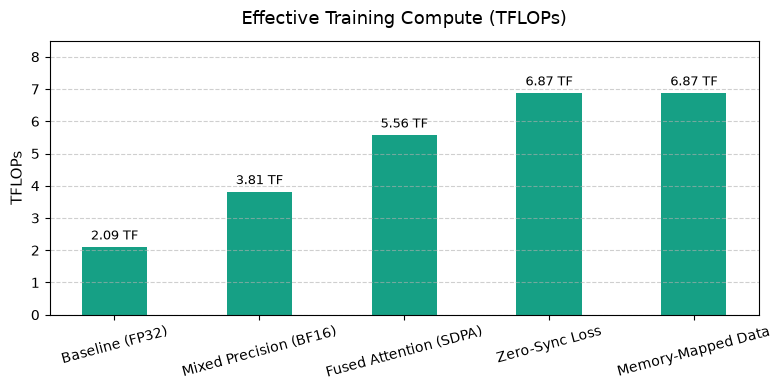

In [3]:
# 2. Hardware Compute Throughput (TFLOPs)
# Theoretical FLOPs per token for 124M model during training = 6 * P
num_params = 124.44e6
tflops = [(6 * num_params * t) / 1e12 for t in tokens_per_sec]

plt.figure(figsize=(8, 4))
bars = plt.bar(stages, tflops, color="#16a085", width=0.45)
plt.title("Effective Training Compute (TFLOPs)", fontsize=13, pad=12)
plt.ylabel("TFLOPs", fontsize=11)
plt.ylim(0, 8.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=15)

for bar, val in zip(bars, tflops):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.15, f"{val:.2f} TF", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


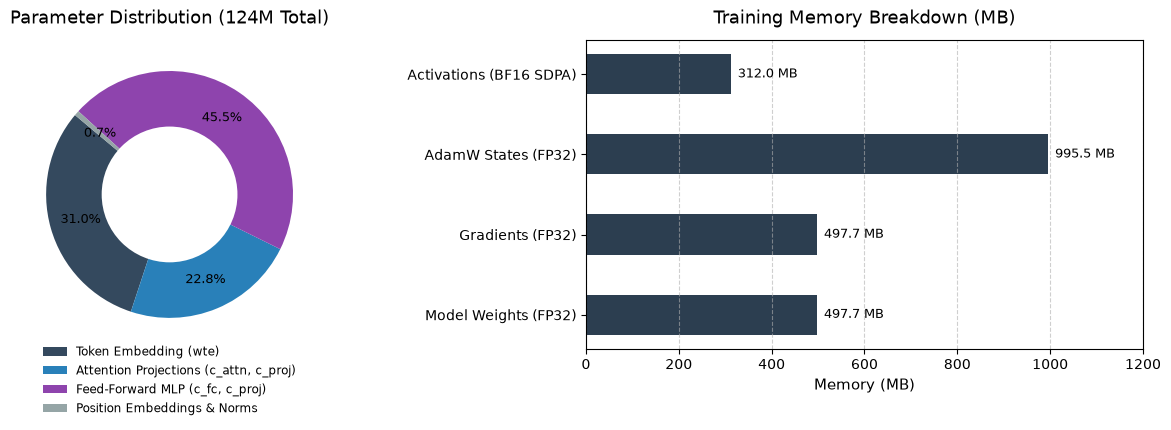

In [4]:
# 3. Model Architecture & Parameter Distribution
categories = [
    "Token Embedding (wte)",
    "Attention Projections (c_attn, c_proj)",
    "Feed-Forward MLP (c_fc, c_proj)",
    "Position Embeddings & Norms"
]
param_counts = [
    50257 * 768,               # 38.6M
    12 * (768 * 2304 + 768 * 768),  # 28.3M
    12 * (768 * 3072 + 3072 * 768), # 56.6M
    (1024 * 768) + (12 * 4 * 768 + 2 * 768) # 0.8M
]
param_mb = [p * 4 / (1024 * 1024) for p in param_counts] # FP32 size in MB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Donut chart
colors = ["#34495e", "#2980b9", "#8e44ad", "#95a5a6"]
ax1.pie(param_counts, labels=None, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.75, textprops={'fontsize': 9})
centre_circle = plt.Circle((0,0), 0.55, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title("Parameter Distribution (124M Total)", fontsize=13, pad=12)
ax1.legend(categories, loc="lower center", bbox_to_anchor=(0.5, -0.25), fontsize=8.5, frameon=False)

# Training Memory Breakdown per Model Instance (Batch Size = 4, Sequence = 1024)
mem_categories = ["Model Weights (FP32)", "Gradients (FP32)", "AdamW States (FP32)", "Activations (BF16 SDPA)"]
mem_mb = [497.7, 497.7, 995.5, 312.0] # MB

ax2.barh(mem_categories, mem_mb, color="#2c3e50", height=0.5)
ax2.set_title("Training Memory Breakdown (MB)", fontsize=13, pad=12)
ax2.set_xlabel("Memory (MB)", fontsize=11)
ax2.set_xlim(0, 1200)
ax2.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(mem_mb):
    ax2.text(v + 15, i, f"{v:.1f} MB", va='center', fontsize=9)

plt.tight_layout()
plt.show()


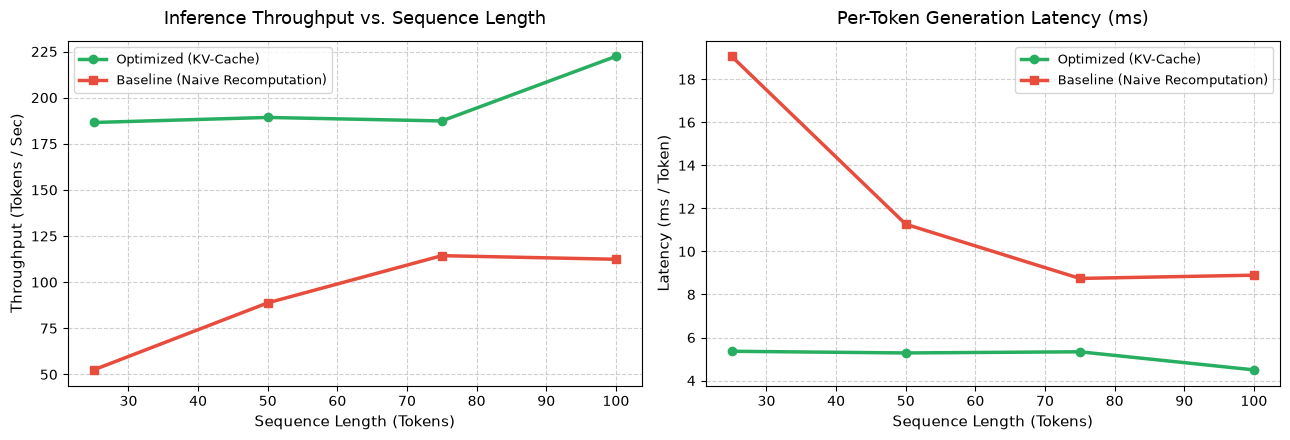

In [5]:
# 4. Inference Speed & Latency Benchmark
cfg = GPTConfig(block_size=1024, vocab_size=50257, n_layer=12, n_head=12, n_embd=768)
model = GPT(cfg).to(device)
model.eval()

enc = tiktoken.get_encoding("gpt2")
prompt = "Once upon a time in a ancient kingdom"
lengths = [25, 50, 75, 100]

naive_tok_s = []
kv_tok_s = []
naive_ms_per_tok = []
kv_ms_per_tok = []

for l in lengths:
    num_gen = l - len(enc.encode(prompt))
    
    # Naive
    if device == "mps": torch.mps.synchronize()
    t0 = time.time()
    _ = generate_samples(model, enc, device, prompt=prompt, num_samples=1, max_length=l)
    if device == "mps": torch.mps.synchronize()
    t_naive = time.time() - t0
    naive_tok_s.append(num_gen / t_naive)
    naive_ms_per_tok.append((t_naive / num_gen) * 1000)
    
    # KV-Cache
    if device == "mps": torch.mps.synchronize()
    t0 = time.time()
    _ = generate_with_cache(model, enc, device, prompt=prompt, num_samples=1, max_length=l)
    if device == "mps": torch.mps.synchronize()
    t_kv = time.time() - t0
    kv_tok_s.append(num_gen / t_kv)
    kv_ms_per_tok.append((t_kv / num_gen) * 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Speed
ax1.plot(lengths, kv_tok_s, marker='o', color="#27ae60", linewidth=2.5, label="Optimized (KV-Cache)")
ax1.plot(lengths, naive_tok_s, marker='s', color="#e74c3c", linewidth=2.5, label="Baseline (Naive Recomputation)")
ax1.set_title("Inference Throughput vs. Sequence Length", fontsize=13, pad=12)
ax1.set_xlabel("Sequence Length (Tokens)", fontsize=11)
ax1.set_ylabel("Throughput (Tokens / Sec)", fontsize=11)
ax1.legend(frameon=True, fontsize=9.5)
ax1.grid(True, linestyle='--', alpha=0.6)

# Latency per token
ax2.plot(lengths, kv_ms_per_tok, marker='o', color="#27ae60", linewidth=2.5, label="Optimized (KV-Cache)")
ax2.plot(lengths, naive_ms_per_tok, marker='s', color="#e74c3c", linewidth=2.5, label="Baseline (Naive Recomputation)")
ax2.set_title("Per-Token Generation Latency (ms)", fontsize=13, pad=12)
ax2.set_xlabel("Sequence Length (Tokens)", fontsize=11)
ax2.set_ylabel("Latency (ms / Token)", fontsize=11)
ax2.legend(frameon=True, fontsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


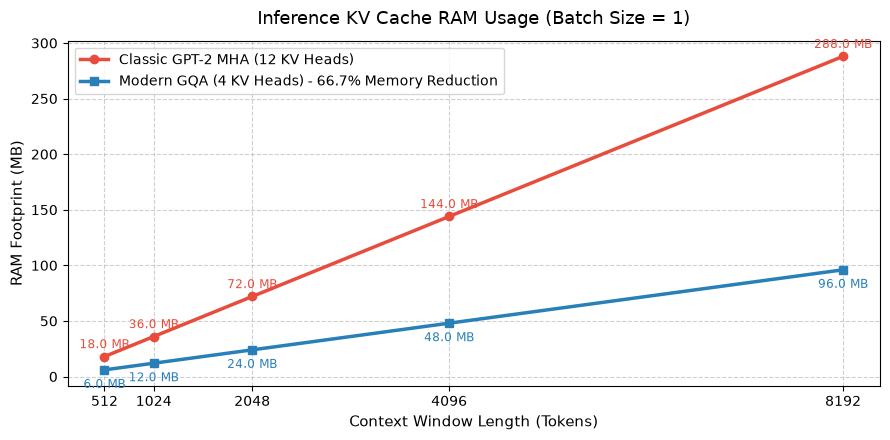

In [6]:
# 5. KV-Cache Memory Footprint: MHA vs. GQA
contexts = np.array([512, 1024, 2048, 4096, 8192])
# Memory = 2 * n_layer * batch_size * seq_len * n_kv_heads * head_dim * 2 bytes (FP16)
mem_mha = (2 * 12 * 1 * contexts * 12 * 64 * 2) / (1024 * 1024)
mem_gqa = (2 * 12 * 1 * contexts * 4 * 64 * 2) / (1024 * 1024)

plt.figure(figsize=(9, 4.5))
plt.plot(contexts, mem_mha, marker='o', color="#e74c3c", linewidth=2.5, label="Classic GPT-2 MHA (12 KV Heads)")
plt.plot(contexts, mem_gqa, marker='s', color="#2980b9", linewidth=2.5, label="Modern GQA (4 KV Heads) - 66.7% Memory Reduction")
plt.title("Inference KV Cache RAM Usage (Batch Size = 1)", fontsize=13, pad=12)
plt.xlabel("Context Window Length (Tokens)", fontsize=11)
plt.ylabel("RAM Footprint (MB)", fontsize=11)
plt.xticks(contexts)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

for x, ym, yg in zip(contexts, mem_mha, mem_gqa):
    plt.annotate(f"{ym:.1f} MB", (x, ym), textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8.5, color="#e74c3c")
    plt.annotate(f"{yg:.1f} MB", (x, yg), textcoords="offset points", xytext=(0, -13), ha='center', fontsize=8.5, color="#2980b9")

plt.tight_layout()
plt.show()


In [7]:
# 6. Live Text Generation Verification
sample = generate_with_cache(model, enc, device, prompt="Once upon a time in a quiet village", num_samples=1, max_length=35)
print("Output text:")
print(sample[0])


Output text:
Once upon a time in a quiet village Elena Chern sitcom encourage Russell Check thr Gripwhy burying doomed extremANReviewtry Buc Hurame Blessinglegate Bentiblingshousinghousing blastediPhone income
